# Задание 2.2 - Введение в PyTorch

Для этого задания потребуется установить версию PyTorch 1.0

https://pytorch.org/get-started/locally/

В этом задании мы познакомимся с основными компонентами PyTorch и натренируем несколько небольших моделей.<br>
GPU нам пока не понадобится.

Основные ссылки:  
https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html  
https://pytorch.org/docs/stable/nn.html  
https://pytorch.org/docs/stable/torchvision/index.html  

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as dset
from torch.utils.data.sampler import SubsetRandomSampler, Sampler

from torchvision import transforms

import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np

## Как всегда, начинаем с загрузки данных

PyTorch поддерживает загрузку SVHN из коробки.

In [12]:
# First, lets load the dataset
data_train = dset.SVHN('./data/', split='train',
                       transform=transforms.Compose([
                           transforms.ToTensor(),
                           transforms.Normalize(mean=[0.43,0.44,0.47],
                                               std=[0.20,0.20,0.20])                           
                       ])
                      )
data_test = dset.SVHN('./data/', split='test', 
                      transform=transforms.Compose([
                           transforms.ToTensor(),
                           transforms.Normalize(mean=[0.43,0.44,0.47],
                                               std=[0.20,0.20,0.20])                           
                       ]))

Теперь мы разделим данные на training и validation с использованием классов `SubsetRandomSampler` и `DataLoader`.

`DataLoader` подгружает данные, предоставляемые классом `Dataset`, во время тренировки и группирует их в батчи.
Он дает возможность указать `Sampler`, который выбирает, какие примеры из датасета использовать для тренировки. Мы используем это, чтобы разделить данные на training и validation.

Подробнее: https://pytorch.org/tutorials/beginner/data_loading_tutorial.html

In [13]:
batch_size = 64

data_size = data_train.data.shape[0]
validation_split = .2
split = int(np.floor(validation_split * data_size))
indices = list(range(data_size))
np.random.shuffle(indices)

train_indices, val_indices = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_indices)
val_sampler = SubsetRandomSampler(val_indices)

train_loader = torch.utils.data.DataLoader(data_train, batch_size=batch_size, 
                                           sampler=train_sampler)
val_loader = torch.utils.data.DataLoader(data_train, batch_size=batch_size,
                                         sampler=val_sampler)

In [14]:
val_loader.dataset.data.shape[0]

73257

В нашей задаче мы получаем на вход изображения, но работаем с ними как с одномерными массивами. Чтобы превратить многомерный массив в одномерный, мы воспользуемся очень простым вспомогательным модулем `Flattener`.

In [15]:
sample, label = data_train[0]
print("SVHN data sample shape: ", sample.shape)
# As you can see, the data is shaped like an image

# We'll use a special helper module to shape it into a tensor
class Flattener(nn.Module):
    def forward(self, x):
        batch_size, *_ = x.shape
        return x.view(batch_size, -1)

SVHN data sample shape:  torch.Size([3, 32, 32])


И наконец, мы создаем основные объекты PyTorch:
- `nn_model` - собственно, модель с нейросетью
- `loss` - функцию ошибки, в нашем случае `CrossEntropyLoss`
- `optimizer` - алгоритм оптимизации, в нашем случае просто `SGD`

In [87]:
nn_model = nn.Sequential(
            Flattener(),
            nn.Linear(3*32*32, 100),
            nn.ReLU(inplace=True),
            nn.Linear(100, 10), 
         )
nn_model.type(torch.FloatTensor)

# We will minimize cross-entropy between the ground truth and
# network predictions using an SGD optimizer
loss = nn.CrossEntropyLoss().type(torch.FloatTensor)
optimizer = optim.SGD(nn_model.parameters(), lr=1e-2, weight_decay=1e-1)

## Тренируем!

Ниже приведена функция `train_model`, реализующая основной цикл тренировки PyTorch.

Каждую эпоху эта функция вызывает функцию `compute_accuracy`, которая вычисляет точность на validation, эту последнюю функцию предлагается реализовать вам.

In [88]:
# This is how to implement the same main train loop in PyTorch. Pretty easy, right?

def train_model(model, train_loader, val_loader, loss, optimizer, num_epochs, scheduler=None):    
    loss_history = []
    train_history = []
    val_history = []
    for epoch in range(num_epochs):
        model.train() # Enter train mode
        
        loss_accum = 0
        correct_samples = 0
        total_samples = 0
        for i_step, (x, y) in enumerate(train_loader):
            prediction = model(x)    
            loss_value = loss(prediction, y)
            optimizer.zero_grad()
            loss_value.backward()
            optimizer.step()
            
            _, indices = torch.max(prediction, 1)
            correct_samples += torch.sum(indices == y)
            total_samples += y.shape[0]
            
            loss_accum += loss_value
        
        if scheduler is not None:
            scheduler.step()

        ave_loss = loss_accum / (i_step + 1)
        train_accuracy = float(correct_samples) / total_samples
        val_accuracy = compute_accuracy(model, val_loader)
        
        loss_history.append(float(ave_loss))
        train_history.append(train_accuracy)
        val_history.append(val_accuracy)
        
        print("Average loss: %f, Train accuracy: %f, Val accuracy: %f" % (ave_loss, train_accuracy, val_accuracy))
        
    return loss_history, train_history, val_history
        
def compute_accuracy(model, loader):
    """
    Computes accuracy on the dataset wrapped in a loader
    
    Returns: accuracy as a float value between 0 and 1
    """
    curr_correct = 0
    total = 0
    model.eval() # Evaluation mode
    with torch.no_grad():
        for x, y in loader:
            pred = model(x)
            ans = torch.argmax(pred, dim=1)
            curr_correct += torch.sum(ans == y)
            total += y.shape[0]

    return curr_correct / total

loss_history, train_history, val_history = train_model(nn_model, train_loader, val_loader, loss, optimizer, 3)

Average loss: 1.820997, Train accuracy: 0.410896, Val accuracy: 0.530612
Average loss: 1.457230, Train accuracy: 0.585435, Val accuracy: 0.602894
Average loss: 1.376635, Train accuracy: 0.622138, Val accuracy: 0.616818


## После основного цикла

Посмотрим на другие возможности и оптимизации, которые предоставляет PyTorch.

Добавьте еще один скрытый слой размера 100 нейронов к модели

In [43]:
# Since it's so easy to add layers, let's add some!

nn_model = nn.Sequential(
    Flattener(),
    nn.Linear(3*32*32, 100),
    nn.ReLU(inplace=True),
    nn.Linear(100, 100), 
    nn.ReLU(inplace=True),
    nn.Linear(100, 10), 
)
nn_model.type(torch.FloatTensor)

optimizer = optim.SGD(nn_model.parameters(), lr=1e-2, weight_decay=1e-1)
loss_history, train_history, val_history = train_model(nn_model, train_loader, val_loader, loss, optimizer, 5)

Average loss: 2.192640, Train accuracy: 0.208682, Val accuracy: 0.221282
Average loss: 2.028310, Train accuracy: 0.262857, Val accuracy: 0.297181
Average loss: 1.828188, Train accuracy: 0.368324, Val accuracy: 0.402157
Average loss: 1.711509, Train accuracy: 0.420657, Val accuracy: 0.424476
Average loss: 1.679317, Train accuracy: 0.434597, Val accuracy: 0.446045


Добавьте слой с Batch Normalization

In [44]:
# We heard batch normalization is powerful, let's use it!

nn_model = nn.Sequential(
    Flattener(),
    nn.Linear(3*32*32, 100),
    nn.BatchNorm1d(100),
    nn.ReLU(inplace=True),
    nn.Linear(100, 100), 
    nn.BatchNorm1d(100),
    nn.ReLU(inplace=True),
    nn.Linear(100, 10), 
)

optimizer = optim.SGD(nn_model.parameters(), lr=1e-3, weight_decay=1e-1)
loss_history, train_history, val_history = train_model(nn_model, train_loader, val_loader, loss, optimizer, 5)

Average loss: 2.053555, Train accuracy: 0.326332, Val accuracy: 0.451232
Average loss: 1.762382, Train accuracy: 0.472409, Val accuracy: 0.508156
Average loss: 1.634515, Train accuracy: 0.531857, Val accuracy: 0.573340
Average loss: 1.551094, Train accuracy: 0.575436, Val accuracy: 0.608354
Average loss: 1.490701, Train accuracy: 0.605655, Val accuracy: 0.616613


Добавьте уменьшение скорости обучения по ходу тренировки.

In [45]:
# Learning rate annealing
# Reduce your learning rate 2x every 2 epochs
# Hint: look up learning rate schedulers in PyTorch. You might need to extend train_model function a little bit too!

nn_model = nn.Sequential(
    Flattener(),
    nn.Linear(3*32*32, 100),
    nn.BatchNorm1d(100),
    nn.ReLU(inplace=True),
    nn.Linear(100, 100), 
    nn.BatchNorm1d(100),
    nn.ReLU(inplace=True),
    nn.Linear(100, 10), 
)

optimizer = optim.SGD(nn_model.parameters(), lr=1e-3, weight_decay=1e-1)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 2.0, 0.5)
loss_history, train_history, val_history = train_model(nn_model, train_loader, val_loader, loss, optimizer, 5, scheduler)

Average loss: 2.067447, Train accuracy: 0.309764, Val accuracy: 0.419084
Average loss: 1.774423, Train accuracy: 0.468672, Val accuracy: 0.517507
Average loss: 1.651919, Train accuracy: 0.529792, Val accuracy: 0.560167
Average loss: 1.598006, Train accuracy: 0.558458, Val accuracy: 0.582281
Average loss: 1.558798, Train accuracy: 0.580009, Val accuracy: 0.588697


# Визуализируем ошибки модели

Попробуем посмотреть, на каких изображениях наша модель ошибается.
Для этого мы получим все предсказания модели на validation set и сравним их с истинными метками (ground truth).

Первая часть - реализовать код на PyTorch, который вычисляет все предсказания модели на validation set.  
Чтобы это сделать мы приводим код `SubsetSampler`, который просто проходит по всем заданным индексам последовательно и составляет из них батчи. 

Реализуйте функцию `evaluate_model`, которая прогоняет модель через все сэмплы validation set и запоминает предсказания модели и истинные метки.

In [50]:
class SubsetSampler(Sampler):
    r"""Samples elements with given indices sequentially

    Arguments:
        indices (ndarray): indices of the samples to take
    """

    def __init__(self, indices):
        self.indices = indices

    def __iter__(self):
        return (self.indices[i] for i in range(len(self.indices)))

    def __len__(self):
        return len(self.indices)
    
    
def evaluate_model(model, dataset, indices):
    """
    Computes predictions and ground truth labels for the indices of the dataset
    
    Returns: 
    predictions: np array of ints - model predictions
    grount_truth: np array of ints - actual labels of the dataset
    """
    model.eval() # Evaluation mode
    
    sampler = SubsetSampler(indices)
    predictions = []
    ground_truth = []
    loader = torch.utils.data.DataLoader(dataset, batch_size=64, sampler=sampler)
    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            pred_classes = torch.argmax(logits, dim=1)
            predictions.extend(pred_classes.numpy())
            ground_truth.extend(y.numpy())
    
    return np.array(predictions), np.array(ground_truth)

# Evaluate model on validation
predictions, gt = evaluate_model(nn_model, data_train, val_indices)
assert len(predictions) == len(val_indices)
assert len(gt) == len(val_indices)
assert gt[100] == data_train[val_indices[100]][1]
assert np.any(np.not_equal(gt, predictions))

## Confusion matrix
Первая часть визуализации - вывести confusion matrix (https://en.wikipedia.org/wiki/Confusion_matrix ).

Confusion matrix - это матрица, где каждой строке соответствуют классы предсказанный, а столбцу - классы истинных меток (ground truth). Число с координатами `i,j` - это количество сэмплов класса `j`, которые модель считает классом `i`.

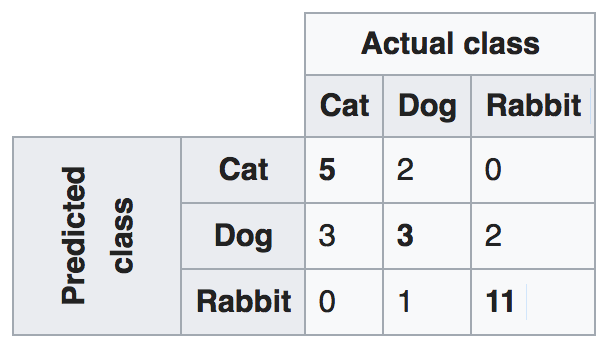

Для того, чтобы облегчить вам задачу, ниже реализована функция `visualize_confusion_matrix` которая визуализирует такую матрицу.  
Вам осталось реализовать функцию `build_confusion_matrix`, которая ее вычислит.

Результатом должна быть матрица 10x10.

In [52]:
print(gt)

[6 4 7 ... 3 3 4]


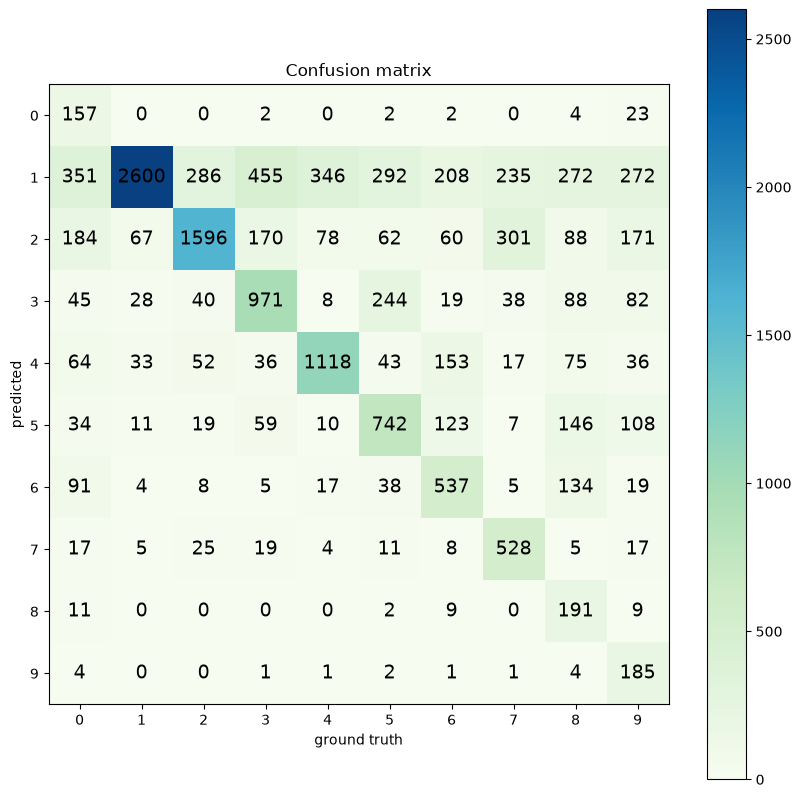

In [57]:
def visualize_confusion_matrix(confusion_matrix):
    """
    Visualizes confusion matrix
    
    confusion_matrix: np array of ints, x axis - predicted class, y axis - actual class
                      [i][j] should have the count of samples that were predicted to be class i,
                      but have j in the ground truth
                     
    """
    # Adapted from 
    # https://stackoverflow.com/questions/2897826/confusion-matrix-with-number-of-classified-misclassified-instances-on-it-python
    assert confusion_matrix.shape[0] == confusion_matrix.shape[1]
    size = confusion_matrix.shape[0]
    fig = plt.figure(figsize=(10,10))
    plt.title("Confusion matrix")
    plt.ylabel("predicted")
    plt.xlabel("ground truth")
    res = plt.imshow(confusion_matrix, cmap='GnBu', interpolation='nearest')
    cb = fig.colorbar(res)
    plt.xticks(np.arange(size))
    plt.yticks(np.arange(size))
    for i, row in enumerate(confusion_matrix):
        for j, count in enumerate(row):
            plt.text(j, i, count, fontsize=14, horizontalalignment='center', verticalalignment='center')
    
def build_confusion_matrix(predictions, ground_truth):
    """
    Builds confusion matrix from predictions and ground truth

    predictions: np array of ints, model predictions for all validation samples
    ground_truth: np array of ints, ground truth for all validation samples
    
    Returns:
    np array of ints, (10,10), counts of samples for predicted/ground_truth classes
    """
    
    confusion_matrix = np.zeros((10,10), int)
    
    for i in range(len(ground_truth)):
        confusion_matrix[predictions[i]][ground_truth[i]] += 1
            
    return confusion_matrix

confusion_matrix = build_confusion_matrix(predictions, gt)
visualize_confusion_matrix(confusion_matrix)

Наконец, посмотрим на изображения, соответствующие некоторым элементам этой матрицы.

Как и раньше, вам дана функция `visualize_images`, которой нужно воспрользоваться при реализации функции `visualize_predicted_actual`. Эта функция должна вывести несколько примеров, соответствующих заданному элементу матрицы.

Визуализируйте наиболее частые ошибки и попробуйте понять, почему модель их совершает.

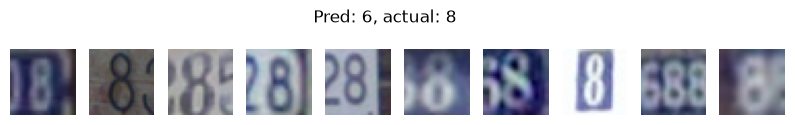

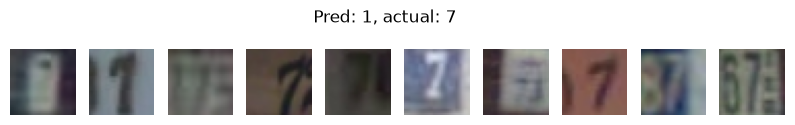

In [ ]:
data_train_images = dset.SVHN('./data/', split='train')

def visualize_images(indices, data, title='', max_num=10):
    """
    Visualizes several images from the dataset
 
    indices: array of indices to visualize
    data: torch Dataset with the images
    title: string, title of the plot
    max_num: int, max number of images to display
    """
    to_show = min(len(indices), max_num)
    fig = plt.figure(figsize=(10,1.5))
    fig.suptitle(title)
    for i, index in enumerate(indices[:to_show]):
        plt.subplot(1,to_show, i+1)
        plt.axis('off')
        sample = data[index][0]
        plt.imshow(sample)
        
def visualize_predicted_actual(predicted_class, gt_class, predictions, groud_truth, val_indices, data):
    """
    Visualizes images of a ground truth class which were predicted as the other class 
    
    predicted: int 0-9, index of the predicted class
    gt_class: int 0-9, index of the ground truth class
    predictions: np array of ints, model predictions for all validation samples
    ground_truth: np array of ints, ground truth for all validation samples
    val_indices: np array of ints, indices of validation samples
    """
    
    mask = (predictions == predicted_class) & (groud_truth == gt_class)
    visualize_images(val_indices[mask], data, title=f'Pred: {predicted_class}, actual: {gt_class}')

visualize_predicted_actual(6, 8, predictions, gt, np.array(val_indices), data_train_images)
visualize_predicted_actual(1, 7, predictions, gt, np.array(val_indices), data_train_images)

# Переходим к свободным упражнениям!

Натренируйте модель как можно лучше - экспериментируйте сами!
Что следует обязательно попробовать:
- перебор гиперпараметров с помощью валидационной выборки
- другие оптимизаторы вместо SGD
- изменение количества слоев и их размеров
- наличие Batch Normalization

Но ограничиваться этим не стоит!

Точность на тестовой выборке должна быть доведена до **80%**

In [92]:
nn_model = nn.Sequential(
    Flattener(),
    nn.Linear(3*32*32, 100),
    nn.BatchNorm1d(100),
    nn.ReLU(inplace=True),
    nn.Linear(100, 100), 
    nn.BatchNorm1d(100),
    nn.ReLU(inplace=True),
    nn.Dropout(),
    nn.Linear(100, 10), 
)

optimizer = optim.AdamW(nn_model.parameters(), lr=1e-3, weight_decay=1e-1)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 2.0, 0.5)
loss_history, train_history, val_history = train_model(nn_model, train_loader, val_loader, loss, optimizer, 10, scheduler)

Average loss: 1.584964, Train accuracy: 0.465123, Val accuracy: 0.628217
Average loss: 1.135965, Train accuracy: 0.640105, Val accuracy: 0.702887
Average loss: 0.952177, Train accuracy: 0.703153, Val accuracy: 0.764658
Average loss: 0.895815, Train accuracy: 0.721667, Val accuracy: 0.766842
Average loss: 0.813988, Train accuracy: 0.749770, Val accuracy: 0.791960
Average loss: 0.788954, Train accuracy: 0.757056, Val accuracy: 0.799195
Average loss: 0.745177, Train accuracy: 0.770928, Val accuracy: 0.806088
Average loss: 0.733232, Train accuracy: 0.774443, Val accuracy: 0.805542
Average loss: 0.706273, Train accuracy: 0.780944, Val accuracy: 0.810525
Average loss: 0.705317, Train accuracy: 0.782787, Val accuracy: 0.814893


In [84]:
learning_rates = [1e-4, 3e-4, 1e-3]
weight_decay = [0, 1e-4, 1e-3, 1e-2]
hidden_layer_size = [128, 256]

best_classifier = None
best_val_accuracy = 0

best_params = {}

for lr in learning_rates:
    for wd in weight_decay:
        for hls in hidden_layer_size:
            nn_model = nn.Sequential(
                Flattener(),
                nn.Linear(3*32*32, hls),
                nn.BatchNorm1d(hls),
                nn.ReLU(inplace=True),
                nn.Linear(hls, 100), 
                nn.BatchNorm1d(100),
                nn.ReLU(inplace=True),
                nn.Dropout(p=0.3),
                nn.Linear(100, 10), 
            )

            optimizer = optim.AdamW(nn_model.parameters(), lr=lr, weight_decay=wd)
            scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 5, 0.5)

            loss_history, train_history, val_history = train_model(nn_model, train_loader, val_loader, loss, optimizer, 10, scheduler)
            
            print(
                f"lr={lr}, reg={wd}, hidden={hls}, "
                f"val={val_history[-1]:.4f} "
                f"train={train_history[-1]:.4f}"
            )

            if val_history[-1] > best_val_accuracy:
                best_val_accuracy = val_history[-1]
                best_classifier = nn_model

                best_params = {
                    "lr": lr,
                    "weight_decay": wd,
                    "hidden_size": hls
                }

print('best validation accuracy achieved: %f' % best_val_accuracy)
print(best_params)

lr=0.0001, reg=0, hidden=128, val=0.8112 train=0.7865
lr=0.0001, reg=0, hidden=256, val=0.8254 train=0.8140
lr=0.0001, reg=0.0001, hidden=128, val=0.8159 train=0.7890
lr=0.0001, reg=0.0001, hidden=256, val=0.8206 train=0.8112
lr=0.0001, reg=0.001, hidden=128, val=0.8156 train=0.7906
lr=0.0001, reg=0.001, hidden=256, val=0.8245 train=0.8104
lr=0.0001, reg=0.01, hidden=128, val=0.8149 train=0.7965
lr=0.0001, reg=0.01, hidden=256, val=0.8286 train=0.8140
lr=0.0003, reg=0, hidden=128, val=0.8218 train=0.8035
lr=0.0003, reg=0, hidden=256, val=0.8326 train=0.8196
lr=0.0003, reg=0.0001, hidden=128, val=0.8258 train=0.8005
lr=0.0003, reg=0.0001, hidden=256, val=0.8294 train=0.8200
lr=0.0003, reg=0.001, hidden=128, val=0.8191 train=0.8000
lr=0.0003, reg=0.001, hidden=256, val=0.8324 train=0.8173
lr=0.0003, reg=0.01, hidden=128, val=0.8204 train=0.8022
lr=0.0003, reg=0.01, hidden=256, val=0.8264 train=0.8131
lr=0.001, reg=0, hidden=128, val=0.8240 train=0.8117
lr=0.001, reg=0, hidden=256, val=0.

In [85]:
# Как всегда, в конце проверяем на test set
test_loader = torch.utils.data.DataLoader(data_test, batch_size=batch_size)
test_accuracy = compute_accuracy(best_classifier, test_loader)
print("Test accuracy: %2.4f" % test_accuracy)

Test accuracy: 0.8193
